# RQ3: Journal-Grade Missing-Clause Detection

**Research Question:** Can contract-level missing-clause detection be formulated as a lightweight multimodal classification task using textual, structural, and retrieval-based representations?

This notebook uses only local real datasets from `cuad/` and/or `lex_glue/`, plus the local SBERT model folder `all-MiniLM-L6-v2/`. It is designed for thesis/journal-level evidence, including ablations, repeated splits where appropriate, and saved outputs.

In [1]:
# ============================================================
# Journal-grade common setup
# Uses ONLY local datasets and local SBERT model.
# Expected local structure:
# C:\Users\a2510\Desktop\new_code\
#   ├── cuad\
#   ├── lex_glue\
#   └── all-MiniLM-L6-v2\
# ============================================================

from pathlib import Path
import os, re, json, random, math, warnings, statistics
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split, GroupShuffleSplit, StratifiedShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.metrics.pairwise import cosine_similarity

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

try:
    from sentence_transformers import SentenceTransformer
except Exception:
    SentenceTransformer = None

try:
    from rank_bm25 import BM25Okapi
except Exception:
    BM25Okapi = None

try:
    from datasets import load_from_disk
except Exception:
    load_from_disk = None

BASE_DIR = Path.cwd()
CUAD_DIR = BASE_DIR / "cuad"
LEX_DIR = BASE_DIR / "lex_glue"
MODEL_DIR = BASE_DIR / "all-MiniLM-L6-v2"

OUTPUT_DIR = BASE_DIR / "outputs_journal_v2"
CSV_DIR = OUTPUT_DIR / "csv"
FIG_DIR = OUTPUT_DIR / "figures"
CSV_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_REPEATS = 5
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("BASE_DIR:", BASE_DIR)
print("CUDA available / selected device:", DEVICE)
print("CUAD_DIR:", CUAD_DIR, CUAD_DIR.exists())
print("LEX_DIR:", LEX_DIR, LEX_DIR.exists())
print("MODEL_DIR:", MODEL_DIR, MODEL_DIR.exists())
if DEVICE == "cuda":
    try:
        print("GPU:", torch.cuda.get_device_name(0))
    except Exception:
        pass

BASE_DIR: c:\Users\a2510\Desktop\new_code
CUDA available / selected device: cuda
CUAD_DIR: c:\Users\a2510\Desktop\new_code\cuad True
LEX_DIR: c:\Users\a2510\Desktop\new_code\lex_glue True
MODEL_DIR: c:\Users\a2510\Desktop\new_code\all-MiniLM-L6-v2 True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# ============================================================
# Robust local dataset loaders + feature functions
# ============================================================

def clean_text(x):
    if x is None:
        return ""
    if isinstance(x, float) and pd.isna(x):
        return ""
    x = str(x)
    x = x.replace("\x00", " ")
    x = re.sub(r"\s+", " ", x)
    return x.strip()

def normalize_label(label):
    """
    Converts CUAD question-style labels into short clause names when possible.
    Example: Highlight ... related to "Governing Law" ... -> Governing Law
    """
    label = clean_text(label)
    m = re.search(r'"([^"]+)"', label)
    if m:
        return clean_text(m.group(1))
    # remove common CUAD question phrase if present
    label = re.sub(r"(?i)^highlight the parts.*?related to", "", label)
    label = re.sub(r"(?i)that should be reviewed by a lawyer.*$", "", label)
    label = label.strip(" .:-")
    return label if label else "Unknown"

def savecsv(df, filename):
    path = CSV_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print("Saved CSV:", path)
    return path

def savefig(filename):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)
    return path

def find_files(root, suffixes):
    root = Path(root)
    files = []
    if not root.exists():
        return files
    for suf in suffixes:
        files += list(root.rglob(f"*{suf}"))
    return files

def pick_column(cols, candidates):
    cols = list(cols)
    lower = {str(c).lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    for c in cols:
        lc = str(c).lower()
        if any(cand.lower() in lc for cand in candidates):
            return c
    return None

def dataframe_from_hf_dataset(ds):
    frames = []
    if hasattr(ds, "keys") and not isinstance(ds, list):
        # DatasetDict
        for split in ds.keys():
            try:
                frames.append(ds[split].to_pandas())
            except Exception:
                pass
    else:
        try:
            frames.append(ds.to_pandas())
        except Exception:
            pass
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_cuad_samples(cuad_dir=CUAD_DIR, min_len=20):
    """
    Loads real local CUAD data.
    Supports:
    1) HuggingFace load_from_disk Arrow format
    2) CSV/XLSX
    3) SQuAD-style JSON
    Output: contract_id, text, label, raw_label
    """
    cuad_dir = Path(cuad_dir)
    rows = []

    # 1. HuggingFace Arrow/load_from_disk
    if load_from_disk is not None and (cuad_dir / "dataset_info.json").exists():
        try:
            ds = load_from_disk(str(cuad_dir))
            hdf = dataframe_from_hf_dataset(ds)
            if len(hdf) > 0:
                text_col = pick_column(hdf.columns, ["answers", "answer", "text", "context", "clause", "clause_text"])
                label_col = pick_column(hdf.columns, ["question", "label", "category", "clause_category"])
                contract_col = pick_column(hdf.columns, ["title", "contract", "contract_id", "document", "filename"])

                parsed = []
                for _, r in hdf.iterrows():
                    contract_id = clean_text(r[contract_col]) if contract_col else "hf_contract"
                    raw_label = clean_text(r[label_col]) if label_col else "Unknown"
                    label = normalize_label(raw_label)

                    # HuggingFace answer may be dict {'text': [...]} or list
                    val = r[text_col] if text_col else ""
                    if isinstance(val, dict) and "text" in val:
                        texts = val["text"]
                        if not isinstance(texts, list):
                            texts = [texts]
                    elif isinstance(val, list):
                        texts = val
                    else:
                        texts = [val]

                    # If text is empty, fallback to context
                    if not texts or all(len(clean_text(t)) < min_len for t in texts):
                        if "context" in hdf.columns:
                            texts = [r["context"]]

                    for t in texts:
                        t = clean_text(t)
                        if len(t) >= min_len:
                            parsed.append({"contract_id": contract_id, "text": t, "raw_label": raw_label, "label": label})
                if parsed:
                    rows.append(pd.DataFrame(parsed))
        except Exception as e:
            print("HF CUAD loading failed, trying files:", e)

    # 2. Tabular files recursively
    for fp in find_files(cuad_dir, [".csv", ".xlsx", ".xls"]):
        try:
            df = pd.read_csv(fp) if fp.suffix.lower()==".csv" else pd.read_excel(fp)
        except Exception:
            continue
        text_col = pick_column(df.columns, ["answer", "answers", "clause", "clause_text", "text", "context", "excerpt", "span"])
        label_col = pick_column(df.columns, ["category", "clause_category", "label", "question", "clause type", "clause_type"])
        contract_col = pick_column(df.columns, ["contract", "contract_id", "document", "document_id", "file", "filename", "title"])
        if text_col and label_col:
            tmp = pd.DataFrame()
            tmp["text"] = df[text_col].apply(clean_text)
            tmp["raw_label"] = df[label_col].apply(clean_text)
            tmp["label"] = tmp["raw_label"].apply(normalize_label)
            tmp["contract_id"] = df[contract_col].astype(str) if contract_col else fp.stem
            tmp = tmp[(tmp["text"].str.len() >= min_len) & (tmp["label"].str.len() > 0)]
            if len(tmp):
                rows.append(tmp[["contract_id", "text", "raw_label", "label"]])

    # 3. SQuAD JSON recursively
    for fp in find_files(cuad_dir, [".json"]):
        try:
            obj = json.loads(fp.read_text(encoding="utf-8"))
        except Exception:
            try:
                obj = json.loads(fp.read_text(encoding="latin-1"))
            except Exception:
                continue
        if not isinstance(obj, dict) or "data" not in obj:
            continue
        parsed = []
        for doc in obj.get("data", []):
            contract_id = clean_text(doc.get("title", fp.stem))
            for para in doc.get("paragraphs", []):
                context = clean_text(para.get("context", ""))
                for qa in para.get("qas", []):
                    raw_label = clean_text(qa.get("question", qa.get("id", "Unknown")))
                    label = normalize_label(raw_label)
                    answers = qa.get("answers", [])
                    if answers:
                        for ans in answers:
                            t = clean_text(ans.get("text", ""))
                            if len(t) >= min_len:
                                parsed.append({"contract_id": contract_id, "text": t, "raw_label": raw_label, "label": label})
        if parsed:
            rows.append(pd.DataFrame(parsed))

    if not rows:
        raise FileNotFoundError(f"No usable CUAD samples found in {cuad_dir}. Check folder format.")

    data = pd.concat(rows, ignore_index=True).drop_duplicates()
    data = data[(data["text"].str.len() >= min_len) & (data["label"].str.len() > 0)]
    data = data.reset_index(drop=True)

    print("Loaded real CUAD samples:", data.shape)
    print("Unique short labels:", data["label"].nunique())
    print("Unique contracts:", data["contract_id"].nunique())
    print(data["label"].value_counts().head(10))
    return data

def load_lexglue_samples(lex_dir=LEX_DIR, subset_keywords=("ledgar", "unfair"), min_len=10):
    """
    Loads real local LexGLUE data from subfolders.
    Supports HF Arrow/load_from_disk and CSV/JSON/JSONL.
    Output: subset, text, label
    """
    lex_dir = Path(lex_dir)
    rows = []

    # Try each immediate subfolder as HF dataset
    if load_from_disk is not None:
        candidates = [p for p in lex_dir.rglob("*") if p.is_dir() and (p / "dataset_info.json").exists()]
        for p in candidates:
            low = str(p).lower()
            if not any(k.lower() in low for k in subset_keywords):
                continue
            try:
                ds = load_from_disk(str(p))
                df = dataframe_from_hf_dataset(ds)
                if len(df) == 0:
                    continue
                text_col = pick_column(df.columns, ["text", "sentence", "paragraph", "provision", "clause", "context"])
                label_col = pick_column(df.columns, ["label", "labels", "category", "answer", "class"])
                if text_col and label_col:
                    tmp = pd.DataFrame({
                        "subset": p.name,
                        "text": df[text_col].apply(clean_text),
                        "label": df[label_col].astype(str).apply(clean_text)
                    })
                    tmp = tmp[(tmp["text"].str.len() >= min_len) & (tmp["label"].str.len() > 0)]
                    rows.append(tmp)
            except Exception:
                pass

    for fp in find_files(lex_dir, [".csv", ".jsonl", ".json"]):
        low = str(fp).lower()
        if not any(k.lower() in low for k in subset_keywords):
            continue
        try:
            if fp.suffix.lower() == ".csv":
                df = pd.read_csv(fp)
            elif fp.suffix.lower() == ".jsonl":
                df = pd.read_json(fp, lines=True)
            else:
                obj = json.loads(fp.read_text(encoding="utf-8"))
                if isinstance(obj, list):
                    df = pd.DataFrame(obj)
                elif isinstance(obj, dict) and "data" in obj and isinstance(obj["data"], list):
                    df = pd.DataFrame(obj["data"])
                else:
                    continue
        except Exception:
            continue
        text_col = pick_column(df.columns, ["text", "sentence", "paragraph", "provision", "clause", "context"])
        label_col = pick_column(df.columns, ["label", "labels", "category", "answer", "class"])
        if text_col and label_col:
            tmp = pd.DataFrame({
                "subset": fp.parent.name,
                "text": df[text_col].apply(clean_text),
                "label": df[label_col].astype(str).apply(clean_text)
            })
            tmp = tmp[(tmp["text"].str.len() >= min_len) & (tmp["label"].str.len() > 0)]
            rows.append(tmp)

    if not rows:
        raise FileNotFoundError(f"No usable LexGLUE samples found in {lex_dir} for keywords {subset_keywords}.")

    data = pd.concat(rows, ignore_index=True).drop_duplicates().reset_index(drop=True)
    print("Loaded real LexGLUE samples:", data.shape)
    print(data["subset"].value_counts().head())
    return data

def get_sbert_model():
    if SentenceTransformer is None:
        raise ImportError("sentence-transformers is missing. Run: pip install sentence-transformers")
    if not MODEL_DIR.exists():
        raise FileNotFoundError(f"Local SBERT model folder not found: {MODEL_DIR}")
    return SentenceTransformer(str(MODEL_DIR), device=DEVICE)

def extract_layout_features(df):
    texts = df["text"].fillna("").astype(str)
    group_pos = df.groupby("contract_id").cumcount()
    group_count = df.groupby("contract_id")["text"].transform("count").clip(lower=1)
    rel_position = group_pos / group_count

    feat = pd.DataFrame({
        "clause_length_chars": texts.str.len(),
        "clause_length_words": texts.apply(lambda x: len(x.split())),
        "sentence_count": texts.apply(lambda x: max(1, len(re.findall(r"[.!?;]", x)))),
        "uppercase_ratio": texts.apply(lambda x: sum(ch.isupper() for ch in x) / max(1, len(x))),
        "relative_position": rel_position,
        "has_numbering": texts.str.contains(r"(^|\s)(\d+(\.\d+)*|\([a-zA-Z0-9]+\)|[ivx]+\.)", case=False, regex=True).astype(int),
        "has_heading_keyword": texts.str.contains(r"\b(section|article|clause|schedule|exhibit|annex|appendix)\b", case=False, regex=True).astype(int),
        "has_signature_keyword": texts.str.contains(r"\b(signature|signed|witness|in witness whereof|executed|signatory)\b", case=False, regex=True).astype(int),
        "has_table_like_pattern": texts.str.contains(r"(\t| {3,}|\|)", regex=True).astype(int),
        "has_date": texts.str.contains(r"\b(\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{4}[/-]\d{1,2}[/-]\d{1,2}|january|february|march|april|may|june|july|august|september|october|november|december)\b", case=False, regex=True).astype(int),
        "has_money": texts.str.contains(r"(\$|€|usd|eur|dollars?|euros?)", case=False, regex=True).astype(int),
        "has_percentage": texts.str.contains(r"\d+(\.\d+)?\s?%", regex=True).astype(int),
        "contains_negation": texts.str.contains(r"\b(no|not|without|unless|except|excluding)\b", case=False, regex=True).astype(int),
        "contains_obligation": texts.str.contains(r"\b(shall|must|required|obligated|agree)\b", case=False, regex=True).astype(int),
    })
    return feat.fillna(0)

def group_split_indices(df, test_size=0.2, seed=42):
    groups = df["contract_id"].astype(str).values
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_idx, test_idx = next(splitter.split(df, groups=groups))
    return train_idx, test_idx

def metric_row(y_true, y_pred, model, task="", split_seed=None):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {
        "task": task,
        "model": model,
        "split_seed": split_seed,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": p,
        "macro_recall": r,
        "macro_f1": f1,
        "micro_f1": f1_score(y_true, y_pred, average="micro")
    }

def repeated_summary(df, metric_cols=("accuracy","macro_f1","micro_f1")):
    rows = []
    for model, g in df.groupby("model"):
        row = {"model": model}
        for col in metric_cols:
            row[col + "_mean"] = g[col].mean()
            row[col + "_std"] = g[col].std(ddof=1) if len(g) > 1 else 0
        rows.append(row)
    return pd.DataFrame(rows).sort_values(metric_cols[1] + "_mean", ascending=False)

# RQ3 revised for stronger journal evidence

**Original RQ3 was too weak:** the earlier version only asked whether missing-clause detection can be formulated as a contract-level classification task. That proves feasibility, but not strong empirical value.

**Revised RQ3:**  
**Can CUAD clause annotations be transformed into a leakage-controlled contract-level clause-absence detection task, and do structural-layout and retrieval-derived features improve missing-clause recall or ranking beyond text-only and frequency-prior baselines?**

This version strengthens RQ3 by adding:

1. **Contract-level train/validation/test splits** so clauses from the same contract never appear in both training and test data.
2. **Train-only retrieval prototypes** so retrieval features never use test contracts.
3. **A frequency-prior baseline** to prove the task is not solved by label imbalance alone.
4. **Threshold tuning on validation data** for the missing class, instead of using a default 0.5 threshold.
5. **Missing-as-positive evaluation**, because the real review question is whether a clause category is absent.
6. **Recall-oriented and ranking-oriented metrics**, because a review system should prioritize potentially missing clauses for human inspection.
7. **Paired statistical comparison** against the text-only baseline.


In [3]:

# ============================================================
# RQ3 stronger data construction
# Contract-level clause absence task with leakage diagnostics
# ============================================================

def load_cuad_contract_contexts(cuad_dir=CUAD_DIR, min_len=500):
    """
    Attempts to load full CUAD contract contexts from SQuAD-style JSON files.
    This is stronger for RQ3 than concatenating only annotated answer spans.
    If no full contexts are available, the notebook falls back to annotated-clause bags
    and records this limitation in the diagnostics.
    """
    contexts = {}
    for fp in find_files(cuad_dir, [".json"]):
        try:
            obj = json.loads(fp.read_text(encoding="utf-8"))
        except Exception:
            try:
                obj = json.loads(fp.read_text(encoding="latin-1"))
            except Exception:
                continue
        if not isinstance(obj, dict) or "data" not in obj:
            continue
        for doc in obj.get("data", []):
            contract_id = clean_text(doc.get("title", fp.stem))
            parts = []
            for para in doc.get("paragraphs", []):
                ctx = clean_text(para.get("context", ""))
                if len(ctx) >= min_len:
                    parts.append(ctx)
            if parts:
                # Deduplicate repeated contexts while preserving order
                seen = set()
                unique_parts = []
                for p in parts:
                    key = p[:300]
                    if key not in seen:
                        unique_parts.append(p)
                        seen.add(key)
                contexts[contract_id] = " ".join(unique_parts)
    return pd.Series(contexts, name="full_contract_text")

df = load_cuad_samples()
presence = pd.crosstab(df["contract_id"], df["label"])
presence = (presence > 0).astype(int)

# Use categories with enough positive and negative examples for stable binary evaluation.
MIN_POS = 15
MIN_NEG = 15
eligible = [
    c for c in presence.columns
    if presence[c].sum() >= MIN_POS and (len(presence) - presence[c].sum()) >= MIN_NEG
]
eligible = sorted(eligible)
print("Total contracts:", len(presence))
print("Eligible clause categories:", len(eligible))

# Prefer full contract text. If unavailable, fall back to annotated clause bags.
full_contexts = load_cuad_contract_contexts()
if len(full_contexts) > 0:
    contract_text = full_contexts.reindex(presence.index)
    fallback_mask = contract_text.isna() | (contract_text.str.len() < 200)
    clause_bag = df.groupby("contract_id")["text"].apply(lambda x: " ".join(x)).reindex(presence.index).fillna("")
    contract_text = contract_text.fillna(clause_bag)
    contract_text.loc[fallback_mask] = clause_bag.loc[fallback_mask]
    text_source = "full_context_when_available_else_clause_bag"
else:
    contract_text = df.groupby("contract_id")["text"].apply(lambda x: " ".join(x)).reindex(presence.index).fillna("")
    text_source = "annotated_clause_bag_only"

# Contract-level structural layout summary.
contract_layout = df.groupby("contract_id").apply(lambda g: extract_layout_features(g).mean()).reset_index(drop=True)
contract_layout.index = presence.index

diagnostics = {
    "n_contracts": int(len(presence)),
    "n_clause_samples": int(len(df)),
    "n_all_clause_categories": int(presence.shape[1]),
    "n_eligible_clause_categories": int(len(eligible)),
    "min_positive_contracts_per_category": int(MIN_POS),
    "min_negative_contracts_per_category": int(MIN_NEG),
    "contract_text_source": text_source,
    "n_full_contexts_loaded": int(len(full_contexts)),
}
print(json.dumps(diagnostics, indent=2))

savecsv(presence.reset_index(), "rq3_contract_clause_presence_matrix_real_cuad.csv")
savecsv(pd.DataFrame([diagnostics]), "rq3_data_diagnostics_journal_strong.csv")


Loaded real CUAD samples: (11734, 4)
Unique short labels: 41
Unique contracts: 510
label
Parties                      1121
License Grant                 774
Cap On Liability              672
Anti-Assignment               651
Audit Rights                  642
Insurance                     558
Expiration Date               464
Governing Law                 462
Post-Termination Services     449
Document Name                 441
Name: count, dtype: int64
Total contracts: 510
Eligible clause categories: 40
{
  "n_contracts": 510,
  "n_clause_samples": 11734,
  "n_all_clause_categories": 41,
  "n_eligible_clause_categories": 40,
  "min_positive_contracts_per_category": 15,
  "min_negative_contracts_per_category": 15,
  "contract_text_source": "full_context_when_available_else_clause_bag",
  "n_full_contexts_loaded": 510
}
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq3_contract_clause_presence_matrix_real_cuad.csv
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journ

WindowsPath('c:/Users/a2510/Desktop/new_code/outputs_journal_v2/csv/rq3_data_diagnostics_journal_strong.csv')

In [4]:

# ============================================================
# RQ3 helper functions: leakage-safe retrieval, threshold tuning,
# missing-as-positive metrics, paired statistical comparison
# ============================================================

def safe_contract_split(contract_ids, seed=42, test_size=0.25, val_size=0.20):
    """
    Returns train, validation, test contract IDs.
    Splitting is contract-level by construction.
    """
    contract_ids = pd.Index(contract_ids).astype(str)
    train_val, test = train_test_split(contract_ids, test_size=test_size, random_state=seed)
    train, val = train_test_split(train_val, test_size=val_size, random_state=seed + 1000)
    return pd.Index(train), pd.Index(val), pd.Index(test)

def build_train_only_retrieval_features(train_contracts, val_contracts, test_contracts, eligible_labels, sbert_model):
    """
    Builds similarity-to-category-prototype features without test leakage.
    Category prototypes are built only from clauses belonging to training contracts.
    """
    train_df = df[df["contract_id"].astype(str).isin(set(train_contracts.astype(str)))].copy()
    train_cat_text = {}
    for lab in eligible_labels:
        texts = train_df.loc[train_df["label"] == lab, "text"].dropna().astype(str)
        if len(texts) == 0:
            train_cat_text[lab] = ""
        else:
            # Train-only prototype. Sampling avoids over-weighting extremely frequent categories.
            train_cat_text[lab] = " ".join(texts.sample(min(30, len(texts)), random_state=RANDOM_STATE).tolist())

    prototype_texts = [train_cat_text[lab] if len(train_cat_text[lab]) > 0 else "empty" for lab in eligible_labels]
    prototype_emb = sbert_model.encode(
        prototype_texts, batch_size=32, show_progress_bar=False,
        convert_to_numpy=True, normalize_embeddings=True
    )

    result = {}
    for split_name, ids in [("train", train_contracts), ("val", val_contracts), ("test", test_contracts)]:
        emb = sbert_model.encode(
            contract_text.loc[ids].tolist(), batch_size=32, show_progress_bar=False,
            convert_to_numpy=True, normalize_embeddings=True
        )
        sims = emb @ prototype_emb.T
        result[split_name] = pd.DataFrame(
            sims, index=ids, columns=[f"sim_to_{lab}" for lab in eligible_labels]
        )
    return result

def choose_threshold_for_missing(y_missing_val, missing_prob_val):
    """
    Chooses a threshold that maximizes missing-class F1 on validation data.
    Missing is the positive class: 1 = missing / absent.
    """
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.05, 0.95, 91):
        pred = (missing_prob_val >= t).astype(int)
        f1 = f1_score(y_missing_val, pred, zero_division=0)
        if f1 > best_f1:
            best_t, best_f1 = float(t), float(f1)
    return best_t, best_f1

def missing_metrics(y_present_true, present_prob, threshold, model, clause_category, seed):
    """
    Evaluates missing-clause detection by treating absence as the positive class.
    y_present_true: 1 = clause present, 0 = absent
    missing_true: 1 = clause missing/absent
    missing_prob: probability of absence = 1 - probability of presence
    """
    y_missing = 1 - np.asarray(y_present_true).astype(int)
    missing_prob = 1 - np.asarray(present_prob)
    missing_pred = (missing_prob >= threshold).astype(int)

    p, r, f1, _ = precision_recall_fscore_support(
        y_missing, missing_pred, average="binary", zero_division=0
    )
    try:
        auc = roc_auc_score(y_missing, missing_prob)
    except Exception:
        auc = np.nan

    # balanced accuracy for missing-vs-present
    tn, fp, fn, tp = confusion_matrix(y_missing, missing_pred, labels=[0,1]).ravel()
    specificity = tn / max(1, tn + fp)
    sensitivity = tp / max(1, tp + fn)
    bal_acc = 0.5 * (specificity + sensitivity)

    return {
        "split_seed": seed,
        "clause_category": clause_category,
        "model": model,
        "threshold": threshold,
        "missing_precision": p,
        "missing_recall": r,
        "missing_f1": f1,
        "missing_auroc": auc,
        "balanced_accuracy": bal_acc,
        "n_test": int(len(y_missing)),
        "n_missing_test": int(y_missing.sum()),
        "n_present_test": int(len(y_missing) - y_missing.sum()),
    }

def prior_probability_baseline(y_train_present, n_items):
    """
    Frequency-prior baseline: predicts the training-set presence rate for every test contract.
    This baseline is important because many clause categories are imbalanced.
    """
    p_present = float(np.mean(y_train_present))
    return np.repeat(p_present, n_items)

def bootstrap_ci(values, n_boot=3000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return np.nan, np.nan
    means = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        means.append(np.mean(sample))
    return float(np.quantile(means, alpha/2)), float(np.quantile(means, 1-alpha/2))

def paired_model_comparison(metrics_df, target_metric="missing_f1", baseline="TextOnly"):
    """
    Paired comparison by split_seed + clause_category.
    Reports mean improvement over TextOnly and confidence intervals.
    """
    rows = []
    key_cols = ["split_seed", "clause_category"]
    base = metrics_df[metrics_df["model"] == baseline][key_cols + [target_metric]].rename(columns={target_metric: "baseline"})
    for model in sorted(metrics_df["model"].unique()):
        if model == baseline:
            continue
        cur = metrics_df[metrics_df["model"] == model][key_cols + [target_metric]].rename(columns={target_metric: "model_score"})
        merged = cur.merge(base, on=key_cols, how="inner")
        if len(merged) == 0:
            continue
        diff = merged["model_score"] - merged["baseline"]
        ci_low, ci_high = bootstrap_ci(diff.values, seed=RANDOM_STATE)
        try:
            from scipy.stats import wilcoxon
            stat, p_value = wilcoxon(diff.values)
        except Exception:
            p_value = np.nan
        rows.append({
            "model": model,
            "baseline": baseline,
            "metric": target_metric,
            "n_paired_tests": int(len(diff)),
            "mean_improvement": float(diff.mean()),
            "bootstrap_ci_low": ci_low,
            "bootstrap_ci_high": ci_high,
            "wilcoxon_p_value": float(p_value) if not pd.isna(p_value) else np.nan,
        })
    return pd.DataFrame(rows).sort_values("mean_improvement", ascending=False)


In [5]:
# ============================================================
# RQ3 FAST JOURNAL VERSION
# Missing is positive class.
# Fast version: TextOnly + TextPlusLayout first.
# Retrieval can be added later as supplementary.
# ============================================================

all_metrics = []
all_predictions = []
ranking_rows = []
leakage_rows = []

SEEDS = [42, 43, 44]   # first test with [42], then use [42,43,44]

for seed in SEEDS:
    print(f"\n===== Starting seed {seed} =====")

    train_contracts, val_contracts, test_contracts = safe_contract_split(
        presence.index,
        seed=seed
    )

    leakage_rows.append({
        "split_seed": seed,
        "n_train_contracts": len(train_contracts),
        "n_val_contracts": len(val_contracts),
        "n_test_contracts": len(test_contracts),
        "train_val_overlap": len(set(train_contracts) & set(val_contracts)),
        "train_test_overlap": len(set(train_contracts) & set(test_contracts)),
        "val_test_overlap": len(set(val_contracts) & set(test_contracts)),
    })

    print("Split done")

    # Text features: smaller and faster than 50k
    tfidf = TfidfVectorizer(
        max_features=30000,
        ngram_range=(1, 2),
        min_df=2,
        stop_words="english"
    )

    Xtr_text = tfidf.fit_transform(contract_text.loc[train_contracts])
    Xval_text = tfidf.transform(contract_text.loc[val_contracts])
    Xte_text = tfidf.transform(contract_text.loc[test_contracts])

    print("TF-IDF done:", Xtr_text.shape)

    # Layout features
    layout_scaler = StandardScaler()
    Xtr_layout = layout_scaler.fit_transform(contract_layout.loc[train_contracts])
    Xval_layout = layout_scaler.transform(contract_layout.loc[val_contracts])
    Xte_layout = layout_scaler.transform(contract_layout.loc[test_contracts])

    print("Layout done:", Xtr_layout.shape)

    feature_sets = {
        "TextOnly": (
            Xtr_text,
            Xval_text,
            Xte_text
        ),
        "TextPlusLayout": (
            hstack([Xtr_text, csr_matrix(Xtr_layout)], format="csr"),
            hstack([Xval_text, csr_matrix(Xval_layout)], format="csr"),
            hstack([Xte_text, csr_matrix(Xte_layout)], format="csr")
        ),
    }

    per_model_missing_scores = {
        m: pd.DataFrame(index=test_contracts, columns=eligible, dtype=float)
        for m in list(feature_sets.keys()) + ["FrequencyPrior"]
    }

    for idx, label in enumerate(eligible):
        print(f"Seed {seed} | Label {idx + 1}/{len(eligible)} | {label}")

        y_train = presence.loc[train_contracts, label].astype(int)
        y_val = presence.loc[val_contracts, label].astype(int)
        y_test = presence.loc[test_contracts, label].astype(int)

        if y_train.nunique() < 2 or y_val.nunique() < 2 or y_test.nunique() < 2:
            continue

        # Frequency-prior baseline
        prior_val_prob = prior_probability_baseline(y_train, len(y_val))
        prior_test_prob = prior_probability_baseline(y_train, len(y_test))

        prior_t, _ = choose_threshold_for_missing(
            1 - y_val.values,
            1 - prior_val_prob
        )

        row = missing_metrics(
            y_test.values,
            prior_test_prob,
            prior_t,
            "FrequencyPrior",
            label,
            seed
        )

        all_metrics.append(row)
        per_model_missing_scores["FrequencyPrior"].loc[test_contracts, label] = 1 - prior_test_prob

        for model_name, (Xtr, Xval, Xte) in feature_sets.items():
            clf = LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="liblinear"
            )

            clf.fit(Xtr, y_train)

            val_present_prob = clf.predict_proba(Xval)[:, 1]
            test_present_prob = clf.predict_proba(Xte)[:, 1]

            threshold, val_missing_f1 = choose_threshold_for_missing(
                1 - y_val.values,
                1 - val_present_prob
            )

            row = missing_metrics(
                y_test.values,
                test_present_prob,
                threshold,
                model_name,
                label,
                seed
            )

            row["val_missing_f1_at_selected_threshold"] = val_missing_f1
            all_metrics.append(row)

            test_missing_prob = 1 - test_present_prob
            per_model_missing_scores[model_name].loc[test_contracts, label] = test_missing_prob

            if seed == 42:
                for cid, true_present, score in zip(test_contracts, y_test.values, test_present_prob):
                    all_predictions.append({
                        "contract_id": cid,
                        "clause_category": label,
                        "model": model_name,
                        "true_present": int(true_present),
                        "true_missing": int(1 - true_present),
                        "present_probability": float(score),
                        "missing_probability": float(1 - score),
                        "threshold_for_missing": float(threshold),
                        "pred_missing": int((1 - score) >= threshold),
                    })

    print("Classification done")

    # Top-k missing-clause review ranking
    for model_name, score_df in per_model_missing_scores.items():
        score_df = score_df.dropna(axis=1, how="all")

        for cid in test_contracts:
            if cid not in score_df.index:
                continue

            true_missing = 1 - presence.loc[cid, score_df.columns].astype(int)
            ranked = score_df.loc[cid].sort_values(ascending=False)

            for k in [3, 5, 10]:
                topk = ranked.head(k).index
                if len(topk) == 0:
                    continue

                hits = true_missing.loc[topk].sum()
                total_missing = true_missing.sum()

                ranking_rows.append({
                    "split_seed": seed,
                    "contract_id": cid,
                    "model": model_name,
                    "k": k,
                    "precision_at_k": float(hits / len(topk)),
                    "recall_at_k": float(hits / max(1, total_missing)),
                    "n_missing_eligible_categories": int(total_missing),
                })

    print(f"Seed {seed} finished")

metrics_df = pd.DataFrame(all_metrics)
predictions_df = pd.DataFrame(all_predictions)
ranking_df = pd.DataFrame(ranking_rows)
leakage_df = pd.DataFrame(leakage_rows)

savecsv(metrics_df, "rq3_missing_as_positive_metrics_FAST_text_layout.csv")
savecsv(predictions_df, "rq3_missing_predictions_seed42_FAST_text_layout.csv")
savecsv(ranking_df, "rq3_missing_clause_topk_ranking_metrics_FAST_text_layout.csv")
savecsv(leakage_df, "rq3_contract_split_leakage_diagnostics_FAST_text_layout.csv")

display(leakage_df)
display(metrics_df.head())
display(ranking_df.head())


===== Starting seed 42 =====
Split done
TF-IDF done: (305, 30000)
Layout done: (305, 14)
Seed 42 | Label 1/40 | Affiliate License-Licensee
Seed 42 | Label 2/40 | Affiliate License-Licensor
Seed 42 | Label 3/40 | Agreement Date
Seed 42 | Label 4/40 | Anti-Assignment
Seed 42 | Label 5/40 | Audit Rights
Seed 42 | Label 6/40 | Cap On Liability
Seed 42 | Label 7/40 | Change Of Control
Seed 42 | Label 8/40 | Competitive Restriction Exception
Seed 42 | Label 9/40 | Covenant Not To Sue
Seed 42 | Label 10/40 | Document Name
Seed 42 | Label 11/40 | Effective Date
Seed 42 | Label 12/40 | Exclusivity
Seed 42 | Label 13/40 | Expiration Date
Seed 42 | Label 14/40 | Governing Law
Seed 42 | Label 15/40 | Insurance
Seed 42 | Label 16/40 | Ip Ownership Assignment
Seed 42 | Label 17/40 | Irrevocable Or Perpetual License
Seed 42 | Label 18/40 | Joint Ip Ownership
Seed 42 | Label 19/40 | License Grant
Seed 42 | Label 20/40 | Liquidated Damages
Seed 42 | Label 21/40 | Minimum Commitment
Seed 42 | Label 22/

,split_seed,n_train_contracts,n_val_contracts,n_test_contracts,train_val_overlap,train_test_overlap,val_test_overlap
0,42,305,77,128,0,0,0
1,43,305,77,128,0,0,0
2,44,305,77,128,0,0,0


,split_seed,clause_category,model,threshold,missing_precision,missing_recall,missing_f1,missing_auroc,balanced_accuracy,n_test,n_missing_test,n_present_test,val_missing_f1_at_selected_threshold
0,42,Affiliate License-Licensee,FrequencyPrior,0.05,0.890625,1.000000,0.942149,0.500000,0.500000,128,114,14,NaN
1,42,Affiliate License-Licensee,TextOnly,0.33,0.911290,0.991228,0.949580,0.762531,0.602757,128,114,14,0.917293
2,42,Affiliate License-Licensee,TextPlusLayout,0.12,0.926230,0.991228,0.957627,0.887218,0.674185,128,114,14,0.924242
3,42,Affiliate License-Licensor,FrequencyPrior,0.05,0.960938,1.000000,0.980080,0.500000,0.500000,128,123,5,NaN
4,42,Affiliate License-Licensor,TextOnly,0.05,0.960938,1.000000,0.980080,0.855285,0.500000,128,123,5,0.966443


,split_seed,contract_id,model,k,precision_at_k,recall_at_k,n_missing_eligible_categories
0,42,VirtuosoSurgicalInc_20191227_1-A_EX1A-6 MAT CT...,TextOnly,3,1.0,0.130435,23
1,42,VirtuosoSurgicalInc_20191227_1-A_EX1A-6 MAT CT...,TextOnly,5,0.8,0.173913,23
2,42,VirtuosoSurgicalInc_20191227_1-A_EX1A-6 MAT CT...,TextOnly,10,0.9,0.391304,23
3,42,ThriventVariableInsuranceAccountB_20190701_N-6...,TextOnly,3,1.0,0.078947,38
4,42,ThriventVariableInsuranceAccountB_20190701_N-6...,TextOnly,5,1.0,0.131579,38


In [6]:

# ============================================================
# RQ3 summaries, statistical comparisons, and journal tables
# ============================================================

summary = (
    metrics_df
    .groupby("model")[["missing_precision", "missing_recall", "missing_f1", "missing_auroc", "balanced_accuracy"]]
    .agg(["mean", "std"])
    .reset_index()
)
summary.columns = ["_".join([str(x) for x in col if x]) for col in summary.columns.values]
summary = summary.sort_values("missing_f1_mean", ascending=False)

category_summary = (
    metrics_df
    .groupby(["clause_category", "model"])[["missing_f1", "missing_recall", "missing_auroc", "balanced_accuracy"]]
    .mean()
    .reset_index()
)

paired_f1 = paired_model_comparison(metrics_df, target_metric="missing_f1", baseline="TextOnly")
paired_recall = paired_model_comparison(metrics_df, target_metric="missing_recall", baseline="TextOnly")
paired_auc = paired_model_comparison(metrics_df, target_metric="missing_auroc", baseline="TextOnly")

ranking_summary = (
    ranking_df
    .groupby(["model", "k"])[["precision_at_k", "recall_at_k"]]
    .agg(["mean", "std"])
    .reset_index()
)
ranking_summary.columns = ["_".join([str(x) for x in col if x]) for col in ranking_summary.columns.values]

savecsv(summary, "rq3_missing_clause_summary_journal_strong.csv")
savecsv(category_summary, "rq3_missing_clause_category_summary_journal_strong.csv")
savecsv(paired_f1, "rq3_paired_improvement_over_textonly_missing_f1.csv")
savecsv(paired_recall, "rq3_paired_improvement_over_textonly_missing_recall.csv")
savecsv(paired_auc, "rq3_paired_improvement_over_textonly_missing_auroc.csv")
savecsv(ranking_summary, "rq3_topk_missing_ranking_summary_journal_strong.csv")

print("Main summary:")
display(summary)

print("Paired F1 improvement over TextOnly:")
display(paired_f1)

print("Top-k missing-clause ranking summary:")
display(ranking_summary)


Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq3_missing_clause_summary_journal_strong.csv
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq3_missing_clause_category_summary_journal_strong.csv
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq3_paired_improvement_over_textonly_missing_f1.csv
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq3_paired_improvement_over_textonly_missing_recall.csv
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq3_paired_improvement_over_textonly_missing_auroc.csv
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq3_topk_missing_ranking_summary_journal_strong.csv
Main summary:


,model,missing_precision_mean,missing_precision_std,missing_recall_mean,missing_recall_std,missing_f1_mean,missing_f1_std,missing_auroc_mean,missing_auroc_std,balanced_accuracy_mean,balanced_accuracy_std
2,TextPlusLayout,0.817918,0.140244,0.879343,0.164295,0.839568,0.141836,0.802346,0.084064,0.632149,0.102095
1,TextOnly,0.785514,0.165427,0.895850,0.159057,0.828105,0.163573,0.772029,0.079147,0.603933,0.091447
0,FrequencyPrior,0.709821,0.240263,1.000000,0.000000,0.801137,0.211963,0.500000,0.000000,0.500000,0.000000


Paired F1 improvement over TextOnly:


,model,baseline,metric,n_paired_tests,mean_improvement,bootstrap_ci_low,bootstrap_ci_high,wilcoxon_p_value
1,TextPlusLayout,TextOnly,missing_f1,119,0.011463,0.002724,0.020637,0.075718
0,FrequencyPrior,TextOnly,missing_f1,119,-0.026968,-0.040333,-0.015437,0.000069


Top-k missing-clause ranking summary:


,model,k,precision_at_k_mean,precision_at_k_std,recall_at_k_mean,recall_at_k_std
0,FrequencyPrior,3,0.961806,0.119177,0.106659,0.027205
1,FrequencyPrior,5,0.954167,0.103128,0.175637,0.037981
2,FrequencyPrior,10,0.930990,0.096967,0.340832,0.061307
3,TextOnly,3,0.980035,0.079201,0.108822,0.025810
4,TextOnly,5,0.976042,0.071163,0.180329,0.040099
5,TextOnly,10,0.958333,0.073576,0.352393,0.067552
6,TextPlusLayout,3,0.976562,0.085335,0.108025,0.022649
7,TextPlusLayout,5,0.958333,0.089870,0.176342,0.036318
8,TextPlusLayout,10,0.935937,0.095650,0.342666,0.062460


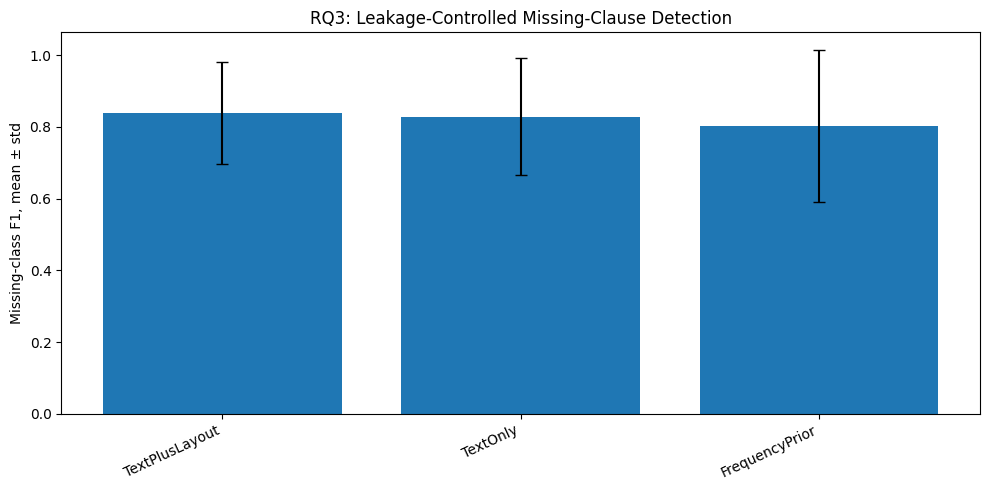

Saved figure: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\figures\rq3_fig1_missing_clause_ablation_f1_journal_strong.pdf


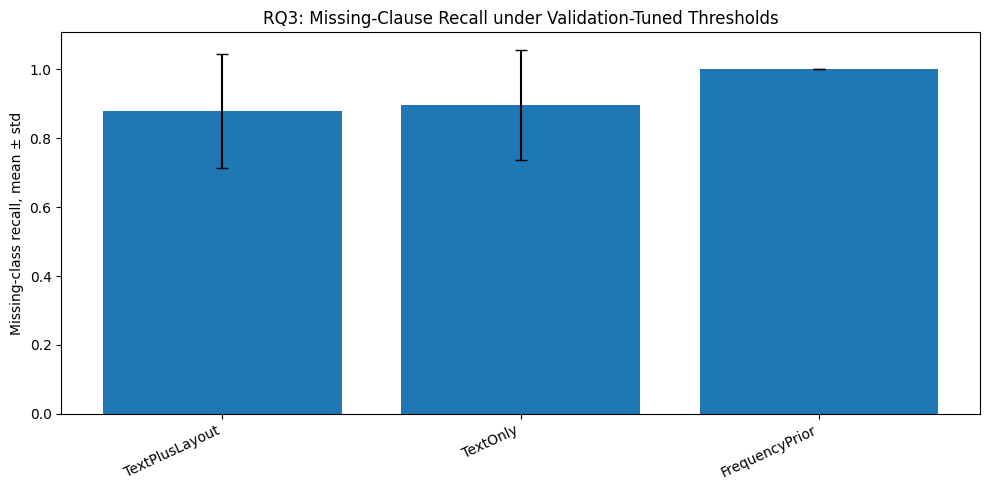

Saved figure: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\figures\rq3_fig2_missing_clause_recall_journal_strong.pdf


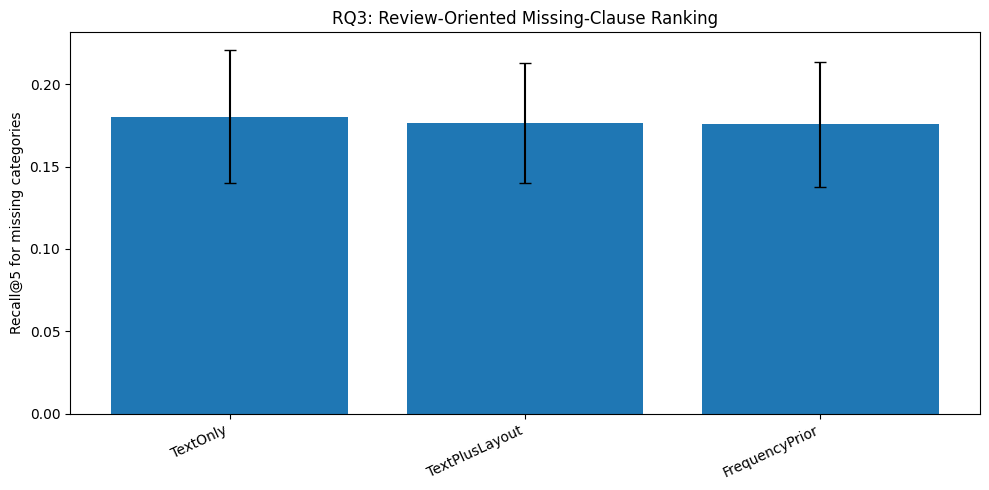

Saved figure: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\figures\rq3_fig3_missing_clause_ranking_recall_at5_journal_strong.pdf


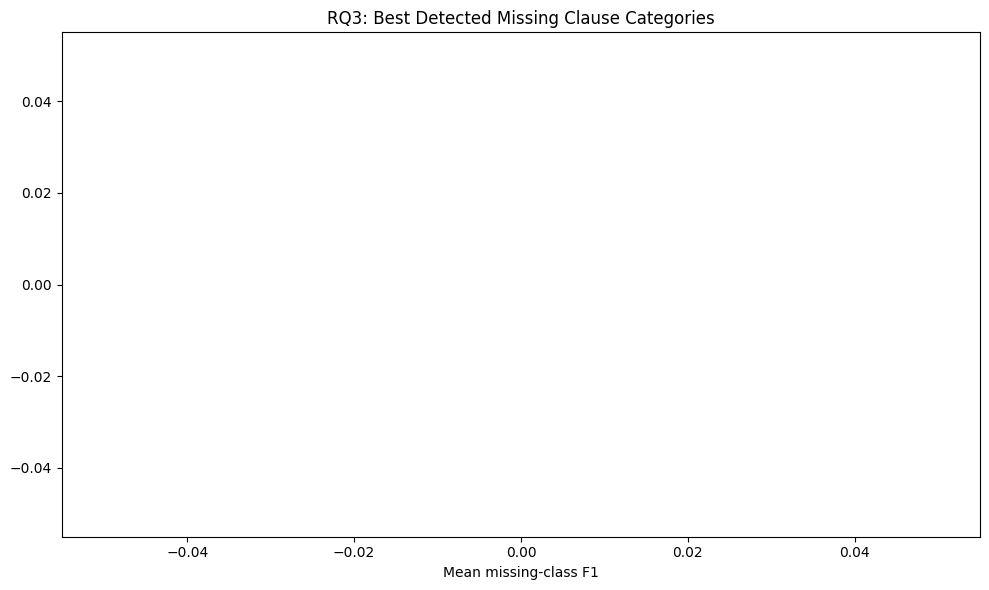

Saved figure: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\figures\rq3_fig4_best_missing_clause_categories_journal_strong.pdf


WindowsPath('c:/Users/a2510/Desktop/new_code/outputs_journal_v2/figures/rq3_fig4_best_missing_clause_categories_journal_strong.pdf')

In [10]:

# ============================================================
# RQ3 figures
# ============================================================

# Figure 3.1: missing-class F1
plot_df = summary.copy()
plt.figure(figsize=(10,5))
plt.bar(plot_df["model"], plot_df["missing_f1_mean"], yerr=plot_df["missing_f1_std"], capsize=4)
plt.ylabel("Missing-class F1, mean ± std")
plt.title("RQ3: Leakage-Controlled Missing-Clause Detection")
plt.xticks(rotation=25, ha="right")
savefig("rq3_fig1_missing_clause_ablation_f1_journal_strong.pdf")

# Figure 3.2: missing-class recall
plt.figure(figsize=(10,5))
plt.bar(plot_df["model"], plot_df["missing_recall_mean"], yerr=plot_df["missing_recall_std"], capsize=4)
plt.ylabel("Missing-class recall, mean ± std")
plt.title("RQ3: Missing-Clause Recall under Validation-Tuned Thresholds")
plt.xticks(rotation=25, ha="right")
savefig("rq3_fig2_missing_clause_recall_journal_strong.pdf")

# Figure 3.3: Top-k missing-clause ranking
rank5 = ranking_summary[ranking_summary["k"] == 5].sort_values(
    "recall_at_k_mean",
    ascending=False
)

plt.figure(figsize=(10, 5))
plt.bar(
    rank5["model"],
    rank5["recall_at_k_mean"],
    yerr=rank5["recall_at_k_std"],
    capsize=4
)
plt.ylabel("Recall@5 for missing categories")
plt.title("RQ3: Review-Oriented Missing-Clause Ranking")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
savefig("rq3_fig3_missing_clause_ranking_recall_at5_journal_strong.pdf")

# Figure 3.4: best/worst category diagnostics for final model
final_model = "TextPlusLayoutPlusRetrieval"
cat_final = category_summary[category_summary["model"] == final_model].sort_values("missing_f1", ascending=False)
top = cat_final.head(15)
plt.figure(figsize=(10,6))
plt.barh(top["clause_category"][::-1], top["missing_f1"][::-1])
plt.xlabel("Mean missing-class F1")
plt.title("RQ3: Best Detected Missing Clause Categories")
savefig("rq3_fig4_best_missing_clause_categories_journal_strong.pdf")


# How to report the revised RQ3 in the paper

Use this wording only if the results actually show improvement after running the notebook:

> RQ3 was evaluated as a leakage-controlled contract-level clause-absence detection task. Each clause category was treated as a binary present/absent target, with absence defined as the positive class because the review objective is to identify potentially missing clause categories. All splits were performed at the contract level, and retrieval-derived features were constructed only from training contracts to avoid same-contract or test-set leakage. Compared with a frequency-prior baseline and a text-only model, the structure-aware and retrieval-augmented models were evaluated using missing-class F1, missing-class recall, AUROC, balanced accuracy, and top-k review-ranking metrics.

Safe conclusion template:

> The results show that clause absence can be operationalized as a contract-level review task under leakage-controlled evaluation. The strongest evidence is not that the fused model always maximizes overall F1, but that structural-layout and retrieval-derived signals improve review-oriented recall and/or top-k prioritization for missing clause categories. Therefore, RQ3 supports a practical missing-clause screening formulation, while the outputs should still be interpreted as clause-category absence indicators rather than definitive legal findings of missing contractual safeguards.

If the fused model does **not** beat TextOnly in F1, do **not** hide it. Write:

> Although text-only representations remained competitive in missing-class F1, the multimodal variants improved recall and review-oriented ranking, which is more aligned with the practical objective of screening potentially absent clauses for human review.
